# Airline Passenger Satisfaction – EDA & KPI Design

## 1. Business context & objectives

In this notebook, we analyse an open airline passenger satisfaction dataset to understand the drivers of satisfaction and dissatisfaction.

The perspective is that of a **Technical Product Owner** working in an Analytics Centre of Excellence (ACoE) for an airline. The focus is on:
- Designing meaningful satisfaction and experience KPIs.
- Performing exploratory data analysis (EDA) by key segments (class, travel type, loyalty, delays).
- Translating findings into product and analytics questions that an ACoE would support.

**Key business questions:**
- What proportion of passengers are satisfied vs neutral/dissatisfied?
- How does satisfaction vary by customer type, travel purpose, and class?
- Which service dimensions (e.g., online booking, wifi, seat comfort) differentiate satisfied from dissatisfied passengers the most?
- How do departure and arrival delays affect satisfaction?

In [59]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'svg'

In [3]:
df_import = pd.read_csv("../data/processed/airline_customer_satisfaction_cleaned.csv")
df = df_import.copy()

In [4]:
df.head()

,satisfaction,customer_type,age,age_bins,travel_type,travel_class,flight_distance,flight_distance_bins,seat_comfort,dep_arr_time_convenient,...,baggage_handling,checkin_service,cleanliness,online_boarding,dep_delay_min,arr_delay_min,dep_delay_bins,arr_delay_bins,is_dep_significantly_delayed,is_arr_significantly_delayed
0,satisfied,loyal,65,61-90,personal,eco,265,0-500,0,0,...,3,5,3,2,0,0,on_time,on_time,False,False
1,satisfied,loyal,47,41-60,personal,business,2464,2001-5000,0,0,...,4,2,3,2,310,305,severe,severe,True,True
2,satisfied,loyal,15,0-25,personal,eco,2138,2001-5000,0,0,...,4,4,4,2,0,0,on_time,on_time,False,False
3,satisfied,loyal,60,41-60,personal,eco,623,501-1000,0,0,...,1,4,1,3,0,0,on_time,on_time,False,False
4,satisfied,loyal,70,61-90,personal,eco,354,0-500,0,0,...,2,4,2,5,0,0,on_time,on_time,False,False


## 2. KPI definition 
_(PO perspective)_

In this section we define and compute the core KPIs that an airline ACoE might expose to stakeholders.

**Example KPIs:**
- Overall passenger satisfaction rate.
- Satisfaction rate by:
  - Customer Type (loyal vs disloyal).
  - Type of Travel (business vs personal).
  - Class (business, eco, eco-plus).
- Satisfaction vs delay:
  - Satisfaction rate by departure delay bucket.
  - Satisfaction rate by arrival delay bucket.
- Satisfaction vs service ratings:
  - Average rating per service dimension for satisfied vs dissatisfied passengers.
  - Difference in averages to highlight biggest gaps.

Each KPI will be presented as:
- A short table.
- One or two clear visualisations (bar charts, grouped bars, or simple heatmaps).
- A short narrative comment from a product/operations perspective.

### Overall Customer Satisfaction
Here, we can see that overall passenger satisfaction rate is 54.74% (70.88K in numbers).

In [5]:
overall_satisfaction = df.satisfaction.value_counts(normalize=True).rename('rate').reset_index()

overall_satisfaction['percentage'] = overall_satisfaction['rate']*100

overall_satisfaction

,satisfaction,rate,percentage
0,satisfied,0.547406,54.74063
1,dissatisfied,0.452594,45.25937


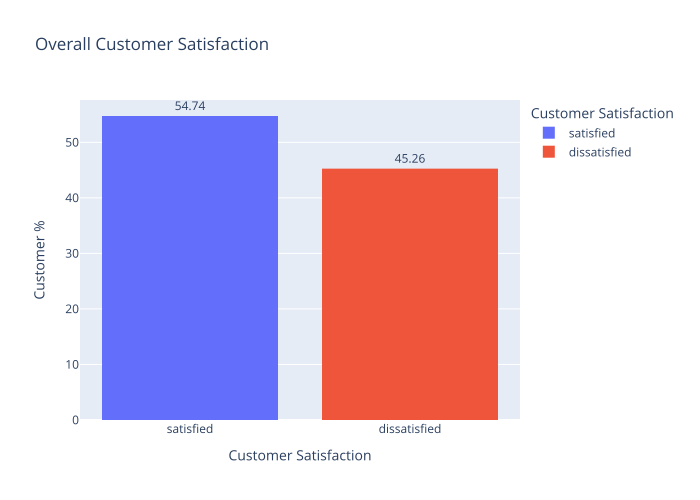

In [176]:
fig_satisfaction = px.histogram(
    overall_satisfaction, 
    x='satisfaction',
    y='percentage',
    labels={'satisfaction': 'Customer Satisfaction'},
    title='Overall Customer Satisfaction',
    color='satisfaction',
    text_auto='0.2f'
)

fig_satisfaction.update_layout(
    yaxis_title = 'Customer %',
)

fig_satisfaction.update_traces(
    textposition='outside'
)

fig_satisfaction

### Satisfaction Rate:

#### Satisfaction rate by customer type

Here, we can see that the satisfaction rate is much higher among loyal customers as compared to disloyal customers.

In [7]:
satisfaction_customer_type = (
    df.groupby('customer_type')['satisfaction'].value_counts(normalize=True).rename('rate').reset_index()
)

satisfaction_customer_type['percentage'] = satisfaction_customer_type['rate']*100

satisfaction_customer_type

,customer_type,satisfaction,rate,percentage
0,disloyal,dissatisfied,0.760142,76.014169
1,disloyal,satisfied,0.239858,23.985831
2,loyal,satisfied,0.616358,61.635767
3,loyal,dissatisfied,0.383642,38.364233


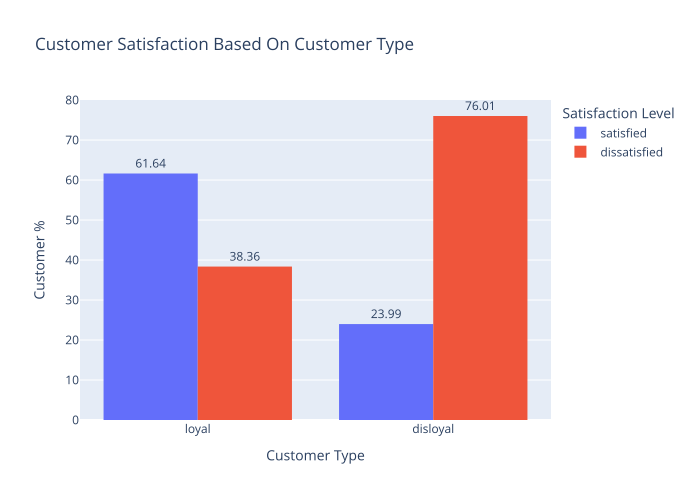

In [180]:
fig_satisfaction_customer_type = px.histogram(
    satisfaction_customer_type.sort_values('satisfaction', ascending=False),
    x='customer_type',
    y='percentage',
    color='satisfaction',
    barmode='group',
    labels={'customer_type': 'Customer Type'},
    category_orders={'customer_type':['loyal','disloyal']},
    text_auto='0.2f',
    title='Customer Satisfaction Based On Customer Type'
)

fig_satisfaction_customer_type.update_layout(
    yaxis_title='Customer %',
    legend_title_text='Satisfaction Level'
)

fig_satisfaction_customer_type.update_traces(
    textposition='outside'
)

Observations:
- Customer satisfaction rate is 61.63% (65.19K in numbers) among `loyal` customers as compared to `disloyal` customers i.e. 23.98% (5.68K in numbers).
- Customer dissatisfaction rate is extremely high among `disloyal` customers i.e. 76.01% (18.03K in numbers) in comparison to `loyal` customers i.e 38.36% (40.58K in numbers).

#### Satisfaction rate by travel type

Here, we can see that the satisfaction rate is higher among customers travelling for business purpose.

In [9]:
satisfaction_travel_type = (
    df.groupby('travel_type')['satisfaction'].value_counts(normalize=True).rename('rate').reset_index()
)

satisfaction_travel_type['percentage'] = satisfaction_travel_type['rate']*100

satisfaction_travel_type

,travel_type,satisfaction,rate,percentage
0,business,satisfied,0.583677,58.367712
1,business,dissatisfied,0.416323,41.632288
2,personal,dissatisfied,0.533615,53.361470
3,personal,satisfied,0.466385,46.638530


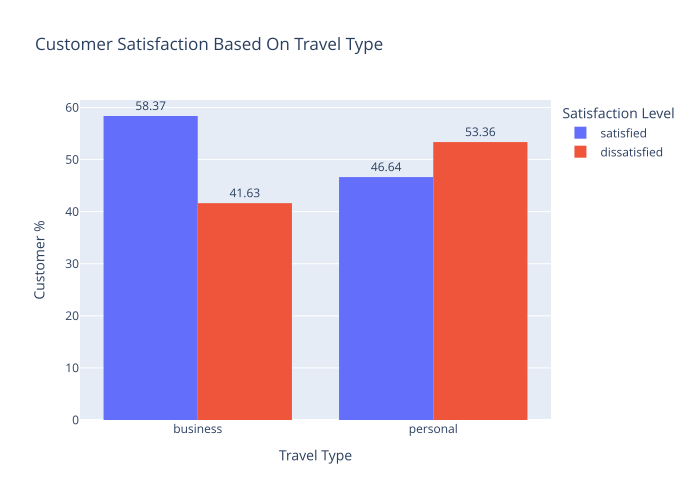

In [179]:
fig_satisfaction_travel_type = px.histogram(
    satisfaction_travel_type,
    x='travel_type',
    y='percentage',
    color='satisfaction',
    barmode='group',
    text_auto='0.2f',
    labels={'travel_type': 'Travel Type'},
    category_orders={'travel_type':['business','personal']},
    title='Customer Satisfaction Based On Travel Type'
)

fig_satisfaction_travel_type.update_layout(
    yaxis_title='Customer %',
    legend_title_text='Satisfaction Level'
)

fig_satisfaction_travel_type.update_traces(
    textposition='outside'
)

Observations:
- Customer satisfaction rate is 58.37% (52.20K in numbers) among customers travelling for `business` purposes as compared to `personal` i.e. 46.64% (18.67K in numbers).
- Customer dissatisfaction rate is 41.63% (37.23K in numbers) among customers travelling for `business` purposes as compared to `personal`  i.e. 53.36% (21.37K in numbers).

#### Satisfaction rate by travel class

Here, we can see that the satisfaction rate is much higher among customers travelling in `business class` and kept going lower in subsequent classes which are `eco plus` and `eco`.

In [11]:
satisfaction_travel_class = (
    df.groupby('travel_class')['satisfaction'].value_counts(normalize=True).rename('rate').reset_index()
)

satisfaction_travel_class['percentage'] = satisfaction_travel_class['rate']*100

satisfaction_travel_class

,travel_class,satisfaction,rate,percentage
0,business,satisfied,0.709421,70.942087
1,business,dissatisfied,0.290579,29.057913
2,eco,dissatisfied,0.606002,60.600169
3,eco,satisfied,0.393998,39.399831
4,eco-plus,dissatisfied,0.572814,57.281450
5,eco-plus,satisfied,0.427186,42.718550


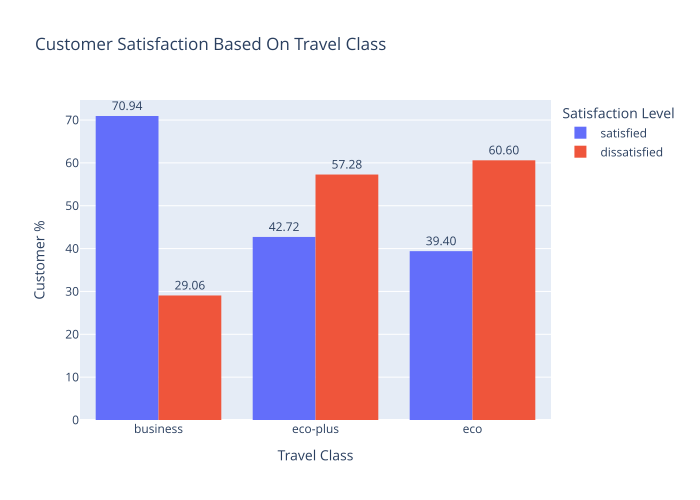

In [173]:
fig_satisfaction_travel_class = px.histogram(
    satisfaction_travel_class,
    x='travel_class',
    y='percentage',
    color='satisfaction',
    barmode='group',
    text_auto='0.2f',
    labels={'travel_class': 'Travel Class'},
    category_orders={'travel_class':['business','eco-plus','eco']},
    title='Customer Satisfaction Based On Travel Class'
)

fig_satisfaction_travel_class.update_layout(
    yaxis_title='Customer %',
    legend_title_text='Satisfaction Level'
)

fig_satisfaction_travel_class.update_traces(
    textposition='outside'
)

Observations:
- Customer satisfaction rate is 70.94% (43.98K in numbers) among customers travelling in travel class `business` in comparison to customers travelling in `eco-plus` and `eco` where it is much lesser i.e. 42.72% (4K in numbers) and 39.40% (22.90K in numbers) respectively.
- Customer dissatisfaction rate is 29.06% (18.01K in numbers) among customers travelling in travel class `business` in comparison to customers travelling in `eco-plus` and `eco` where it is kept rising i.e. 57.28% (5.37K in numbers) and 60.60% (35.22K in numbers) respectively.

### Satisfaction vs Delay:

#### Satisfaction rate by departure delay bucket

Here, we can see that the **satisfaction rate is roughly in 44% to 55% range across all departure delay categories like _minor_, _moderate_, and _severe_**.

**Note:**
_Delay buckets/categories are decided as following:_
- **on_time**: No delay
- **minor**: Upto 15 min delay
- **moderate**: Upto 1 hour delay
- **severe**: More than 1 hour delay

In [13]:
satisfaction_departure_delay = (
    df.groupby('dep_delay_bins')['satisfaction'].value_counts(normalize=True).rename('rate').reset_index()
)

satisfaction_departure_delay['percentage'] = satisfaction_departure_delay['rate']*100

satisfaction_departure_delay

,dep_delay_bins,satisfaction,rate,percentage
0,minor,satisfied,0.553735,55.373511
1,minor,dissatisfied,0.446265,44.626489
2,moderate,dissatisfied,0.504446,50.444636
3,moderate,satisfied,0.495554,49.555364
4,on_time,satisfied,0.572443,57.244328
5,on_time,dissatisfied,0.427557,42.755672
6,severe,dissatisfied,0.563730,56.373045
7,severe,satisfied,0.436270,43.626955


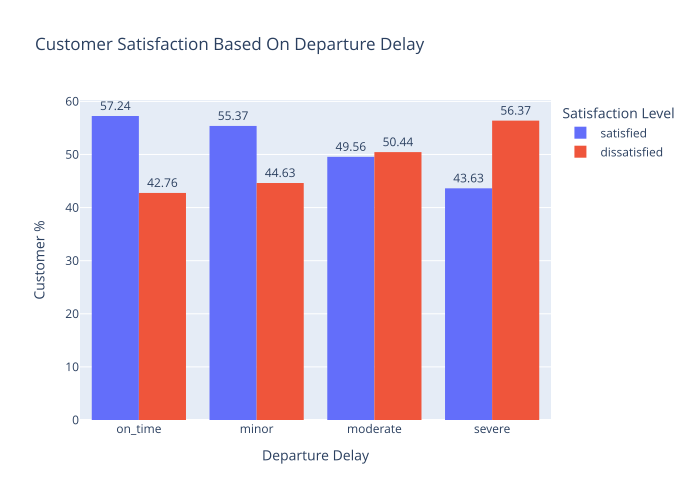

In [169]:
fig_satisfaction_departure_delay = px.histogram(
    satisfaction_departure_delay,
    x='dep_delay_bins',
    y='percentage',
    title='Customer Satisfaction Based On Departure Delay',
    labels={'dep_delay_bins':'Departure Delay'},
    color='satisfaction',
    barmode='group',
    category_orders={'dep_delay_bins':['on_time','minor','moderate','severe']},
    text_auto='0.2f'
)

fig_satisfaction_departure_delay.update_layout(
    yaxis_title='Customer %',
    legend_title_text='Satisfaction Level'
)

fig_satisfaction_departure_delay.update_traces(
    textposition='outside'
)

fig_satisfaction_departure_delay

Observations:
- Customer satisfaction rate is highest 57.24% when the flight is on time and 55.37% for minor delays. Satisfaction rate is kept depreciating based on the delay reaching about 43.62% for severe cases where the flight is delayed for more than an hour.
- Customer dissatisfaction rate is highest 56.37% for severe delays, and kept decresing to 42.76% for on-time departures.

#### Satisfaction rate by arrival delay bucket

Here, we can see that the satisfaction rate is roughly in 44% to 53% range across all departure delay categories like `minor`, `moderate`, and `severe`.

**Note:**
_Delay buckets/categories are decided as following:_
- **on_time**: No delay
- **minor**: Upto 15 min delay
- **moderate**: Upto 1 hour delay
- **severe**: More than 1 hour delay

In [170]:
satisfaction_arrival_delay = (
    df.groupby('arr_delay_bins')['satisfaction'].value_counts(normalize=True).rename('rate').reset_index()
)

satisfaction_arrival_delay['percentage'] = satisfaction_arrival_delay['rate']*100

satisfaction_arrival_delay

,arr_delay_bins,satisfaction,rate,percentage
0,minor,satisfied,0.530468,53.046806
1,minor,dissatisfied,0.469532,46.953194
2,moderate,dissatisfied,0.521251,52.125061
3,moderate,satisfied,0.478749,47.874939
4,on_time,satisfied,0.586684,58.668371
5,on_time,dissatisfied,0.413316,41.331629
6,severe,dissatisfied,0.561730,56.172975
7,severe,satisfied,0.438270,43.827025


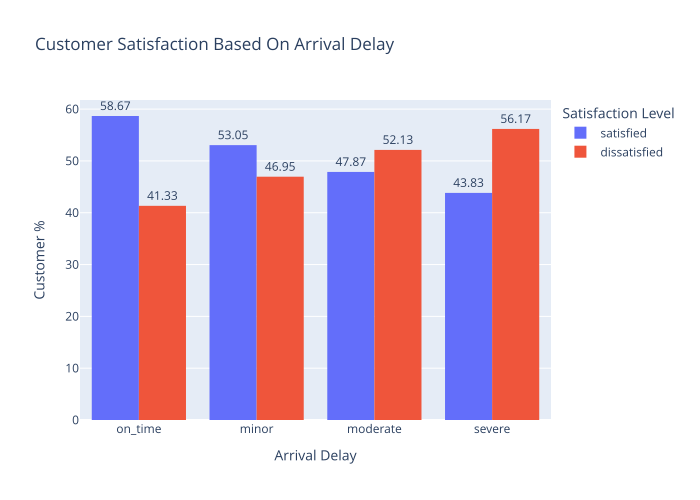

In [171]:
fig_satisfaction_arrival_delay = px.histogram(
    satisfaction_arrival_delay,
    x='arr_delay_bins',
    y='percentage',
    title='Customer Satisfaction Based On Arrival Delay',
    labels={'arr_delay_bins':'Arrival Delay', 'percentage': 'Percentage'},
    color='satisfaction',
    barmode='group',
    category_orders={'arr_delay_bins':['on_time','minor','moderate','severe']},
    text_auto='0.2f'
)

fig_satisfaction_arrival_delay.update_layout(
    yaxis_title='Customer %',
    legend_title_text='Satisfaction Level'
)

fig_satisfaction_arrival_delay.update_traces(
    textposition='outside'
)

fig_satisfaction_arrival_delay

Observations:
- Customer satisfaction rate is highest 58.66% when the flight is on time and 53.05% for minor delays. Satisfaction rate is kept depreciating based on the delay reaching about 43.83% for severe cases where the flight arrival is delayed for more than an hour.
- Customer dissatisfaction rate is highest 56.17% for severe delays, and kept decresing to 41.33% for on-time arrivals.

### Satisfaction vs Service Ratings:

#### Average rating per service dimension for satisfied vs dissatisfied passengers

Here, we can see the comparison of average rating for all services for satisfied vs dissatisfied passengers.

In [17]:
service_columns = [
    'seat_comfort',
    'dep_arr_time_convenient',
    'food_drink',
    'gate_location',
    'inflight_wifi_service',
    'inflight_entertainment',
    'online_support',
    'ease_online_booking',
    'onboard_service',
    'legroom_service',
    'baggage_handling',
    'checkin_service',
    'cleanliness',
    'online_boarding'
]

service_columns_desc = [
    'Seat Comfort',
    'Departure/Arrival Time Convenient',
    'Food/Drink',
    'Gate Location',
    'Inflight Wifi Service',
    'Inflight Entertainment',
    'Online Support',
    'Ease Online Booking',
    'Onboard Service',
    'Legroom Service',
    'Baggage Handling',
    'Checkin Service',
    'Cleanliness',
    'Online Boarding'
]

avg_rating_per_service = (
    df.groupby('satisfaction')[service_columns].mean().round(2)
)

avg_rating_per_service

,seat_comfort,dep_arr_time_convenient,food_drink,gate_location,inflight_wifi_service,inflight_entertainment,online_support,ease_online_booking,onboard_service,legroom_service,baggage_handling,checkin_service,cleanliness,online_boarding
satisfaction,,,,,,,,,,,,,,
dissatisfied,2.47,3.02,2.66,3.01,2.92,2.61,2.96,2.85,2.97,3.05,3.36,2.97,3.38,2.87
satisfied,3.15,2.97,3.01,2.98,3.52,4.02,3.98,3.99,3.87,3.84,3.97,3.65,3.98,3.75


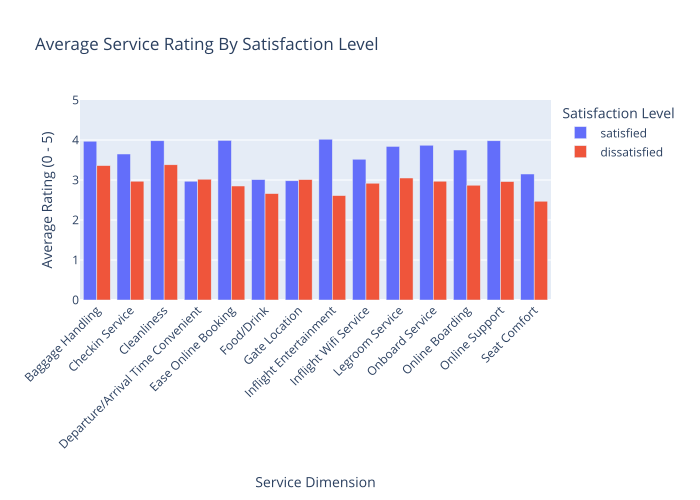

In [130]:
avg_rating_per_service_long = (
    avg_rating_per_service
    .T
    .reset_index()
    .rename(columns={'index':'service'})
    .melt(
        id_vars='service',
        var_name='satisfaction',
        value_name='avg_rating'
    )
    .sort_values(['service','satisfaction'],ascending=[True, False])
)

avg_rating_per_service_long

fig_avg_rating_per_service = px.bar(
    avg_rating_per_service_long,
    x='service',
    y='avg_rating',
    color='satisfaction',
    barmode='group',
    title="Average Service Rating By Satisfaction Level",
    labels={
        'service': 'Service Dimension',
        'avg_rating': 'Average Rating (0 - 5)'
    }
)

fig_avg_rating_per_service.update_xaxes(
     tickvals=service_columns,  # current values
    ticktext=service_columns_desc
)
fig_avg_rating_per_service.update_yaxes(range=[0,5])

fig_avg_rating_per_service.update_layout(
    xaxis_tickangle=-45,
    legend_title_text='Satisfaction Level'
)

fig_avg_rating_per_service

Observations:
- Customer satisfaction rate has no or minor difference in average ratings for certain services e.g.- `Departure/Arrival Time Convenient`, `Food/Drink`, and `Gate Location`.
- Customer dissatisfaction rate is highlighted with some spikes in average ratings for certain services like- `Inflight Entertainment` and `Ease Online Booking`.

#### Difference in averages to highlight biggest gaps

Here, we can see some services has more difference in average ratings for satisfied and dissatisfied customers.

In [19]:
service_avg_difference = (
    avg_rating_per_service.loc['satisfied'] - avg_rating_per_service.loc['dissatisfied']
)

service_avg_difference = (
    service_avg_difference.reset_index()
    .rename(columns={'index':'service', 0:'difference'})
    .sort_values('difference', ascending=False)
)

service_avg_difference

,service,difference
5,inflight_entertainment,1.41
7,ease_online_booking,1.14
6,online_support,1.02
8,onboard_service,0.90
13,online_boarding,0.88
9,legroom_service,0.79
0,seat_comfort,0.68
11,checkin_service,0.68
10,baggage_handling,0.61
4,inflight_wifi_service,0.60


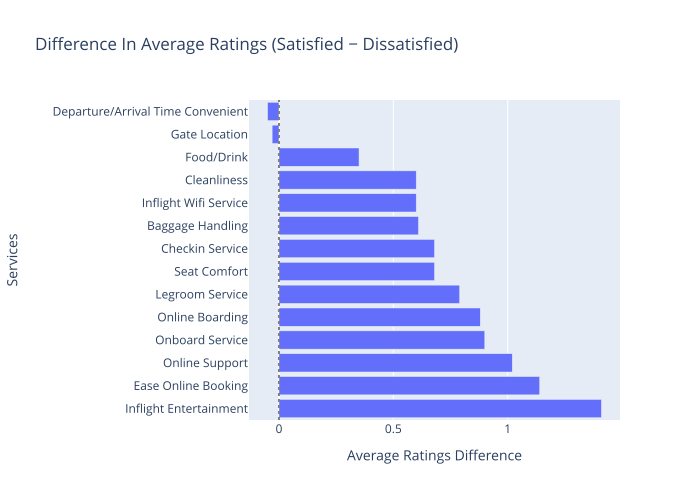

In [20]:
fig_service_avg_difference = px.bar(
    service_avg_difference,
    x='difference',
    y='service',
    labels={'difference':'Average Ratings Difference', 'service':'Services'},
    title='Difference In Average Ratings (Satisfied − Dissatisfied)'
)

fig_service_avg_difference.update_yaxes(
    tickvals=service_columns,
    ticktext=service_columns_desc
)

fig_service_avg_difference.add_vline(x=0, line_dash="dot", line_color="gray")

fig_service_avg_difference

Observations:
- Satisfied customers average rating difference for `Inflight Entertainment`, `Ease in Online Booking` and `Online Support` is more in comparison to dissatisfied customers.
- Some services has negative or very minor contribution to customer satisfaction e.g. `Departure/Arrival Time Convenient`, `Food/Drink`, and `Gate Location`.
- There could be some scope in improving the customer satisfaction by focusing on `Inflight Entertainment`, `Ease in Online Booking` and `Online Support`.

## 3. Exploratory data analysis (segmentation & drivers)

This section deep-dives into patterns behind the KPIs.

### 3.1 Segment analysis

We explore satisfaction across important segments, such as:
- Class vs Type of Travel.
- Customer Type vs Class.
- Age groups vs satisfaction.

For each segment, we:
- Visualise the distribution of satisfied vs dissatisfied.
- Comment on where dissatisfaction is concentrated.

#### Travel Class vs Type of Travel

Here, we can see the customer satisfaction vs dissatisfaction rate by travel class and travel type.

In [22]:
sat_travelclass_traveltype = (
    df
    .groupby(['travel_class', 'travel_type', 'satisfaction'])
    .size()
    .reset_index(name='count')
)

sat_travelclass_traveltype['percent'] = (
    sat_travelclass_traveltype
    .groupby(['travel_class', 'travel_type'])['count']
    .transform(lambda x: x/x.sum() * 100)
)

sat_travelclass_traveltype

,travel_class,travel_type,satisfaction,count,percent
0,business,business,dissatisfied,16588,27.961231
1,business,business,satisfied,42737,72.038769
2,business,personal,dissatisfied,1425,53.470919
3,business,personal,satisfied,1240,46.529081
4,eco,business,dissatisfied,17680,70.072530
5,eco,business,satisfied,7551,29.927470
6,eco,personal,dissatisfied,17539,53.332725
7,eco,personal,satisfied,15347,46.667275
8,eco-plus,business,dissatisfied,2970,60.748619
9,eco-plus,business,satisfied,1919,39.251381


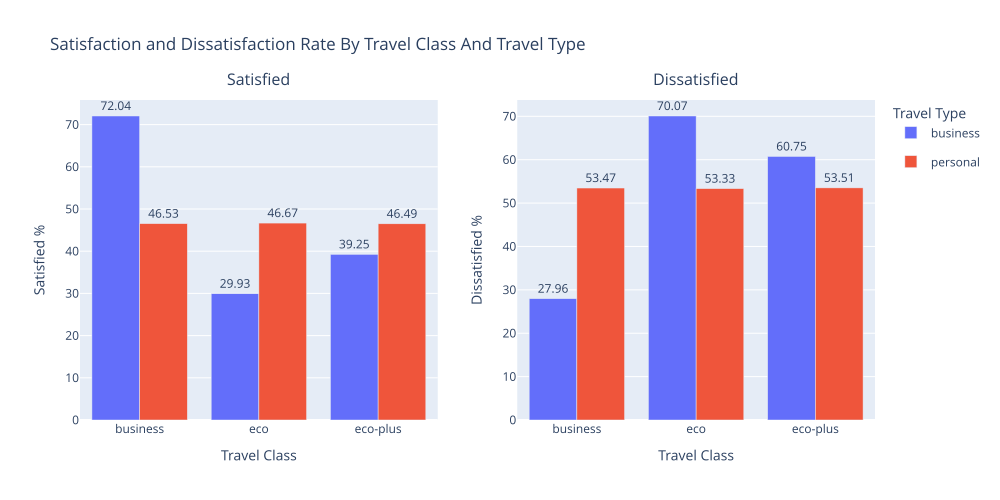

In [158]:

fig_sat_travelclass_traveltype = px.bar(
    sat_travelclass_traveltype[sat_travelclass_traveltype['satisfaction']=='satisfied'],
    x='travel_class',
    y='percent',
    color='travel_type',
    barmode='group',
    labels={'percent':'Satisfied %', 'travel_class':'Travel Class'},
    text_auto='.2f'
)

fig_sat_travelclass_traveltype.update_traces(
    textposition='outside'
)

fig_dissat_travelclass_traveltype = px.bar(
    sat_travelclass_traveltype[sat_travelclass_traveltype['satisfaction']=='dissatisfied'],
    x='travel_class',
    y='percent',
    color='travel_type',
    barmode='group',
    labels={'percent':'Dissatisfied %', 'travel_class':'Travel Class'},
    text_auto='.2f'
)

fig_dissat_travelclass_traveltype.update_traces(
    textposition='outside',
    showlegend=False
)

fig_combined_travelclass_traveltype = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Satisfied', 'Dissatisfied'),
    specs=[[{'secondary_y':False}, {'secondary_y':False}]]
)

fig_combined_travelclass_traveltype.update_annotations(yshift=10)

fig_combined_travelclass_traveltype.add_traces(
    fig_sat_travelclass_traveltype.data,
    rows=1, cols=1
)

fig_combined_travelclass_traveltype.add_traces(
    fig_dissat_travelclass_traveltype.data,
    rows=1, cols=2
)


fig_combined_travelclass_traveltype.update_xaxes(title_text='Travel Class', row=1, col=1)
fig_combined_travelclass_traveltype.update_xaxes(title_text='Travel Class', row=1, col=2)
fig_combined_travelclass_traveltype.update_layout(
    height=500,
    width=1000,
    showlegend=True,
    legend_title_text='Travel Type',
    yaxis_title='Satisfied %',    # left
    yaxis2_title='Dissatisfied %', # right (auto-assigned)
    title_text='Satisfaction and Dissatisfaction Rate By Travel Class And Travel Type'
)

fig_combined_travelclass_traveltype

Observations:
- Customer satisfaction rate is significantly higher when they are travelling in travel class `business` and travel type is `business`.
- Customers travelling in travel class `eco` and `eco-plus` have higher dissatisfaction rate when their travel type is `business`.
- Customer dissatisfaction rate is around 53% when their travel type is `personal` which holds true across all travel classes.

#### Travel Class vs Customer Type

Here, we can see the customer satisfaction vs dissatisfaction rate by travel class and customer type.

In [33]:
sat_travelclass_customertype = (
    df
    .groupby(['travel_class', 'customer_type', 'satisfaction'])
    .size()
    .reset_index(name='count')
)

sat_travelclass_customertype['percent'] = (
    sat_travelclass_customertype
    .groupby(['travel_class', 'customer_type'])['count']
    .transform(lambda x: x/x.sum() * 100)
)

sat_travelclass_customertype

,travel_class,customer_type,satisfaction,count,percent
0,business,disloyal,dissatisfied,5555,60.314875
1,business,disloyal,satisfied,3655,39.685125
2,business,loyal,dissatisfied,12458,23.603638
3,business,loyal,satisfied,40322,76.396362
4,eco,disloyal,dissatisfied,11632,85.579753
5,eco,disloyal,satisfied,1960,14.420247
6,eco,loyal,dissatisfied,23587,52.974733
7,eco,loyal,satisfied,20938,47.025267
8,eco-plus,disloyal,dissatisfied,839,91.995614
9,eco-plus,disloyal,satisfied,73,8.004386


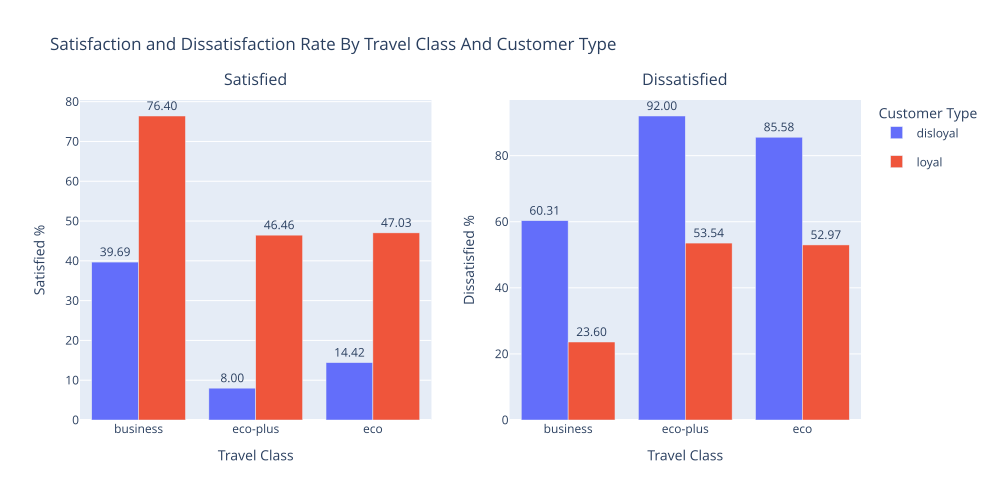

In [161]:
fig_sat_travelclass_customertype = px.bar(
    sat_travelclass_customertype[sat_travelclass_customertype['satisfaction']=='satisfied'],
    x='travel_class',
    y='percent',
    color='customer_type',
    barmode='group',
    labels={'travel_class':'Travel Class', 'percent':'Dissatisfied %'},
    title='Satisfaction Rate By Travel Class And Customer Type',
    text_auto='.2f',
    category_orders={'travel_class':['business', 'eco-plus', 'eco']}
)

fig_sat_travelclass_customertype.update_traces(
    textposition='outside'
)

fig_dissat_travelclass_customertype = px.bar(
    sat_travelclass_customertype[sat_travelclass_customertype['satisfaction']=='dissatisfied'],
    x='travel_class',
    y='percent',
    color='customer_type',
    barmode='group',
    labels={'travel_class':'Travel Class', 'percent':'Dissatisfied %'},
    title='Dissatisfaction Rate By Travel Class And Customer Type',
    text_auto='.2f',
    category_orders={'travel_class':['business', 'eco-plus', 'eco']}
)

fig_dissat_travelclass_customertype.update_traces(
    textposition='outside',
    showlegend=False
)

fig_combined_travelclass_customertype = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Satisfied', 'Dissatisfied'),
    horizontal_spacing=0.1,
    specs=[[{'secondary_y':False}, {'secondary_y':False}]]
)

fig_combined_travelclass_customertype.update_annotations(yshift=10)

fig_combined_travelclass_customertype.add_traces(
    fig_sat_travelclass_customertype.data,
    rows=1, cols=1
)

fig_combined_travelclass_customertype.add_traces(
    fig_dissat_travelclass_customertype.data,
    rows=1, cols=2
)

fig_combined_travelclass_customertype.update_xaxes(
    title_text='Travel Class', 
    row=1, col=1,
    categoryorder="array",
    categoryarray=['business', 'eco-plus', 'eco']
)

fig_combined_travelclass_customertype.update_xaxes(
    title_text='Travel Class', 
    categoryorder="array",
    categoryarray=['business', 'eco-plus', 'eco'],
    row=1, col=2
)

fig_combined_travelclass_customertype.update_layout(
    height=500,
    width=1000,
    showlegend=True,
    legend_title_text='Customer Type',
    yaxis_title='Satisfied %',    # left
    yaxis2_title='Dissatisfied %', # right (auto-assigned)
    title_text='Satisfaction and Dissatisfaction Rate By Travel Class And Customer Type'
)


Observations:
- Customer satisfaction rate is significantly highter across all travel classes for customer type `loyal`.
- Customers with customer type `disloyal` are highly dissatisfied.
- Customers are extremely dissatisfied when travelling in travel class `eco` and `eco-plus` irrespective of customer type with appx. 53% or higher dissatisfaction rate.

#### Age Groups vs Satisfaction

Here, we can see the customer satisfaction vs dissatisfaction rate by age groups.

In [124]:
sat_agegroup = (
    df
    .groupby(['age_bins', 'satisfaction'])
    .size()
    .reset_index(name='count')
    .sort_values('satisfaction',ascending= False)
)

sat_agegroup['percent'] = (
    sat_agegroup
    .groupby('age_bins')['count']
    .transform(lambda x: x/x.sum() * 100)
)

sat_agegroup

,age_bins,satisfaction,count,percent
1,0-25,satisfied,12400,44.145395
3,26-40,satisfied,19351,49.648502
5,41-60,satisfied,34747,66.304742
7,61-90,satisfied,4384,43.765598
0,0-25,dissatisfied,15689,55.854605
2,26-40,dissatisfied,19625,50.351498
4,41-60,dissatisfied,17658,33.695258
6,61-90,dissatisfied,5633,56.234402


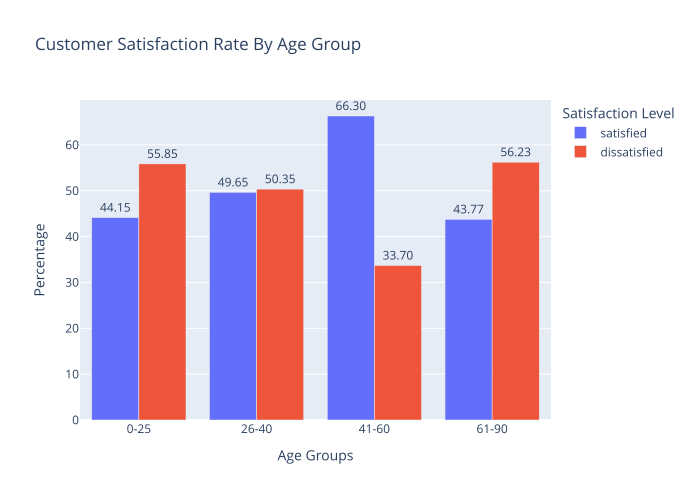

In [129]:
fig_sat_agegroup = px.bar(
    sat_agegroup,
    x='age_bins',
    y='percent',
    title='Customer Satisfaction Rate By Age Group',
    barmode='group',
    color='satisfaction',
    text_auto='.2f',
    labels={'age_bins':'Age Groups', 'percent':'Percentage'}
)

fig_sat_agegroup.update_traces(
    textposition='outside'
)

fig_sat_agegroup.update_layout(
    legend_title_text= 'Satisfaction Level'
)

fig_sat_agegroup

Observations:
- Customer dissatisfaction rate is greater than 50% across all age groups except age group 41-60

### 3.2 Service quality analysis

We:
- Compare distributions of service ratings for satisfied vs dissatisfied passengers.
- Identify which service dimensions have the largest difference between groups.
- Highlight 3–5 service areas that appear most critical (e.g. online boarding, inflight wifi, seat comfort, on-board service).

### 3.3 Delay impact analysis

We:
- Examine the relationship between departure/arrival delays and satisfaction.
- Use delay buckets to see how satisfaction drops as delays increase.
- Comment on which delay thresholds are most harmful to experience.

## 4. Key insights for stakeholders

Here we summarise the most important findings in business language, not statistics.

Examples of statements to capture:
- Which segments (e.g. economy business travellers, disloyal customers) are at greatest risk of dissatisfaction.
- Which service dimensions drive the largest change in satisfaction.
- How strongly delays correlate with dissatisfaction.

For each insight, we briefly outline:
- Potential impact (e.g. churn risk, NPS impact, operational escalations).
- Which stakeholder(s) should care (e.g. operations, digital product, customer experience).

## 5. Implications for product & analytics
_(TPO perspective)_

In this final section of the EDA notebook, we connect the insights to product and analytics work.

We outline:
- Candidate dashboard views / KPIs that the ACoE should maintain (e.g., satisfaction by class and travel type, delay vs satisfaction trends).
- Data quality improvements that may be needed (e.g., better capture of delay reasons).
- Open questions for further analysis (to feed into the backlog).

We do not yet define detailed user stories here; instead, we prepare input for the more structured backlog section in the modeling notebook.